In [1]:
# ============================================================
# STEAM GAMES ANALYTICS — CONSULTORA DE VIDEOJUEGOS
# Ciencia de Datos | Dataset: Top 500 juegos de Steam
# ============================================================

# ============================================================
# BLOQUE 0 — LIBRERÍAS E IMPORTACIÓN DEL DATASET
# ============================================================
# Por qué está acá: todo notebook arranca importando las
# herramientas y cargando los datos. Es la base de todo.

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

uploaded = files.upload()
df = pd.read_csv("steam_games_500_2026.csv", encoding='latin1', sep=';', decimal=',')

print("Dataset cargado correctamente")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(df.columns.tolist())

Saving steam_games_500_2026.csv to steam_games_500_2026.csv
Dataset cargado correctamente
Filas: 500 | Columnas: 11
['AppID', 'Name', 'Release_Date', 'Primary_Genre', 'All_Tags', 'Price_USD', 'Review_Score_Pct_SteamDB', 'Total_Reviews', 'Estimated_Owners', '24h_Peak_Players', 'ADPG']


In [75]:
# ============================================================
# BLOQUE 1 — LIMPIEZA Y PREPARACIÓN DEL DATASET
# ============================================================
# Por qué está acá: los datos crudos siempre tienen problemas.
# Este bloque toma decisiones explícitas sobre qué incluir y
# qué no, y las justifica. Así el análisis siguiente es confiable.
#
# Preguntas que responde:
#   - ¿Qué tan completo es el dataset?
#   - ¿Cómo manejamos los juegos gratis (Price = 0)?
#   - ¿Qué hacemos con juegos sin reviews?

# Definición de ARPU base por género
ARPU_base = {"Action": 13, "Adventure": 9, "RPG": 20, "Strategy": 13, "Simulation": 8, "Casual": 6, "Massively Multiplayer": 22, "Indie": 7, "Sports": 11, "Racing": 9, "Unknown": 10}

# Crear la columna ARPU en el DataFrame principal 'df'
df['ARPU'] = df['Primary_Genre'].map(ARPU_base)

# Si algún género no estuviera en ARPU_base, su ARPU se establecería en NaN.
# Por seguridad, podemos llenar esos valores con el ARPU de 'Unknown'.
df['ARPU'].fillna(value=ARPU_base['Unknown'], inplace=True)

print("=== ANÁLISIS DE VALORES NULOS ===")
print(df.isnull().sum())

print("\n=== DISTRIBUCIÓN DE PRECIOS ===")
print(f"Juegos gratuitos (Price = 0): {(df['Price_USD'] == 0).sum()}")
print(f"Juegos de pago (Price > 0):   {(df['Price_USD'] > 0).sum()}")
print(f"Juegos sin reviews:           {(df['Total_Reviews'] == 0).sum()}")

# --- Decisión de limpieza ---
# Para el análisis de revenue, creamos una columna 'Revenue' que considera:
# - Para juegos de pago: Estimated_Owners * Price_USD * (1 - ADPG) (Net Revenue)
# - Para juegos gratuitos: Estimated_Owners * ARPU (promedio de revenue por usuario)
# Filtramos para incluir solo juegos que tienen al menos una review.

juegos_de_pago = df[df['Price_USD'] > 0].copy()

# Crear un DataFrame para el análisis de revenue que incluya todos los juegos con reviews
df_revenue_analysis = df[df['Total_Reviews'] > 0].copy()

# Calcular la columna 'Revenue' en este nuevo DataFrame
df_revenue_analysis['Revenue'] = df_revenue_analysis.apply(
    lambda row: (row['Estimated_Owners'] * row['Price_USD'] * (1 - row['ADPG'])) if row['Price_USD'] > 0
    else row['Estimated_Owners'] * row['ARPU'],
    axis=1
)

# Actualizar 'juegos_con_revenue' para que apunte a este nuevo DataFrame
juegos_con_revenue = df_revenue_analysis

print(f"\nDataset para análisis de revenue: {juegos_con_revenue.shape[0]} juegos")

=== ANÁLISIS DE VALORES NULOS ===
AppID                       0
Name                        0
Release_Date                0
Primary_Genre               0
All_Tags                    0
Price_USD                   0
Review_Score_Pct_SteamDB    0
Total_Reviews               0
Estimated_Owners            0
24h_Peak_Players            0
ADPG                        0
ARPU                        0
dtype: int64

=== DISTRIBUCIÓN DE PRECIOS ===
Juegos gratuitos (Price = 0): 62
Juegos de pago (Price > 0):   438
Juegos sin reviews:           3

Dataset para análisis de revenue: 497 juegos


/tmp/ipykernel_19662/1268289505.py:21: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





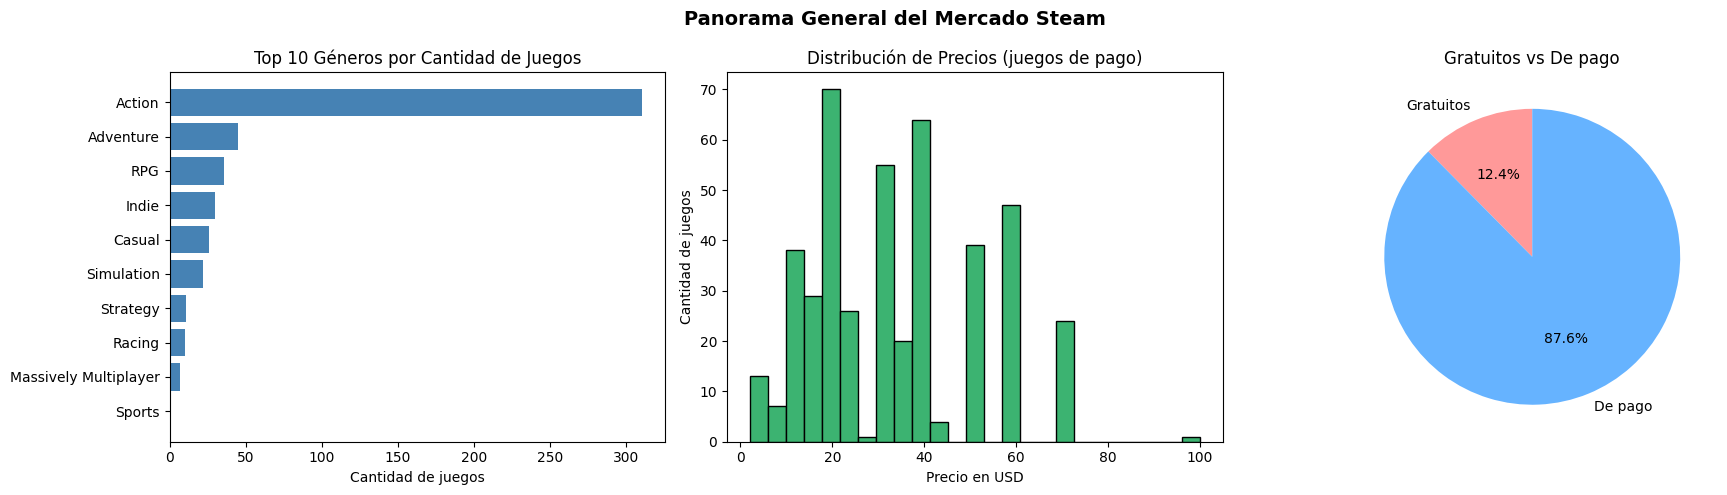

In [76]:
# ============================================================
# BLOQUE 2 — PANORAMA GENERAL DEL MERCADO
# ============================================================
# Por qué está acá: antes de recomendar cualquier estrategia,
# una consultora necesita entender el terreno. Este bloque
# responde las preguntas básicas de contexto.
#
# Preguntas que responde:
#   - ¿Qué géneros dominan el mercado en cantidad?
#   - ¿Cómo se distribuyen los precios?
#   - ¿Qué tan grande es el mercado de juegos gratis vs de pago?

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Panorama General del Mercado Steam', fontsize=14, fontweight='bold')

# Gráfico 1: Top géneros por cantidad
top_generos = df['Primary_Genre'].value_counts().head(10)
axes[0].barh(top_generos.index[::-1], top_generos.values[::-1], color='steelblue')
axes[0].set_title('Top 10 Géneros por Cantidad de Juegos')
axes[0].set_xlabel('Cantidad de juegos')

# Gráfico 2: Distribución de precios (solo de pago)
axes[1].hist(juegos_de_pago['Price_USD'], bins=25, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Distribución de Precios (juegos de pago)')
axes[1].set_xlabel('Precio en USD')
axes[1].set_ylabel('Cantidad de juegos')

# Gráfico 3: Gratis vs de pago
gratis = (df['Price_USD'] == 0).sum()
de_pago = (df['Price_USD'] > 0).sum()
axes[2].pie([gratis, de_pago], labels=['Gratuitos', 'De pago'],
            autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
axes[2].set_title('Gratuitos vs De pago')

plt.tight_layout()
plt.show()

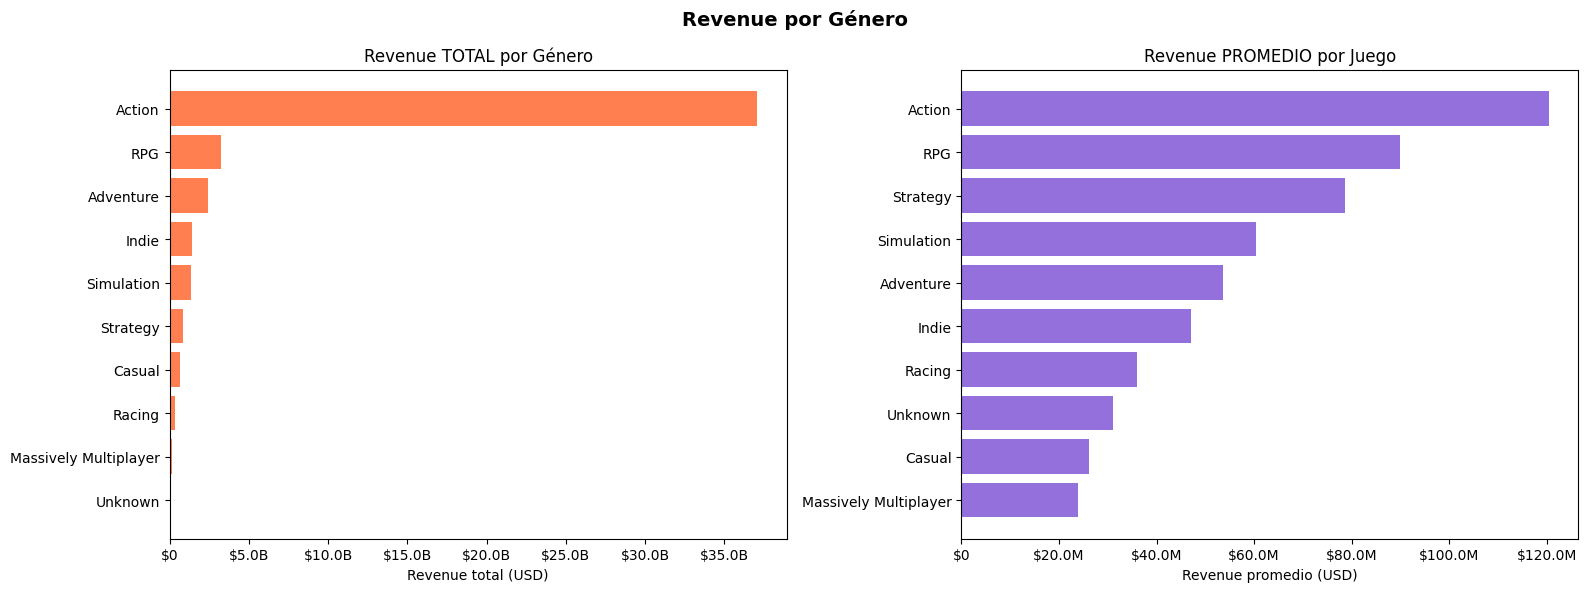

Género con mayor revenue total:   Action
Género con mayor revenue promedio: Action


In [77]:
# ============================================================
# BLOQUE 3 — ANÁLISIS DE REVENUE POR GÉNERO
# ============================================================
# Por qué está acá: el revenue es el indicador económico central.
# Saber qué géneros generan más ingresos le dice a una empresa
# dónde conviene invertir.
#
# Preguntas que responde:
#   - ¿Qué género genera más revenue total?
#   - ¿Qué género tiene mejor revenue promedio por juego?

revenue_total = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].sum().sort_values(ascending=False).head(10)
revenue_promedio = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue por Género', fontsize=14, fontweight='bold')

axes[0].barh(revenue_total.index[::-1], revenue_total.values[::-1], color='coral')
axes[0].set_title('Revenue TOTAL por Género')
axes[0].set_xlabel('Revenue total (USD)')
axes[0].xaxis.set_major_formatter(FuncFormatter(currency_formatter))

axes[1].barh(revenue_promedio.index[::-1], revenue_promedio.values[::-1], color='mediumpurple')
axes[1].set_title('Revenue PROMEDIO por Juego')
axes[1].set_xlabel('Revenue promedio (USD)')
axes[1].xaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.tight_layout()
plt.show()

mejor_total = revenue_total.index[0]
mejor_promedio = revenue_promedio.index[0]

# Pie Chart: Revenue by Primary_Genre
revenue_by_genre = juegos_con_revenue.groupby('Primary_Genre')['Revenue'].sum().reset_index()

fig_pie = px.pie(
    revenue_by_genre,
    values='Revenue',
    names='Primary_Genre',
    title='Porcentaje de Revenue por Género Principal',
    labels={'Primary_Genre': 'Género Principal', 'Revenue': 'Ingresos'},
    hole=0.0 # Optional: creates a donut chart
    )
fig_pie.update_traces(textposition='inside', textinfo='percent+label')
fig_pie.show()

print(f"Género con mayor revenue total:   {mejor_total}")
print(f"Género con mayor revenue promedio: {mejor_promedio}")

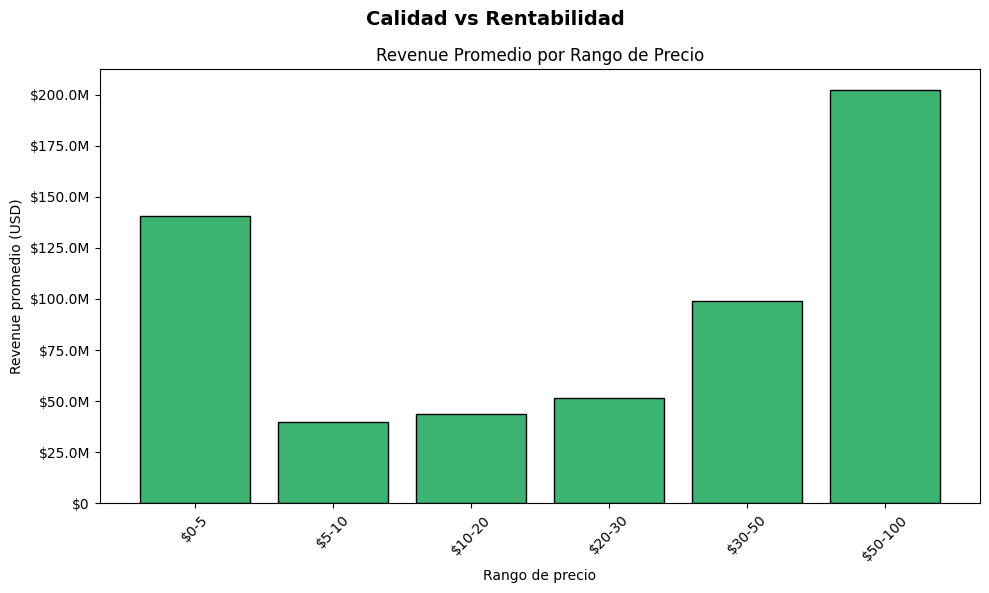

In [78]:
# ============================================================
# BLOQUE 4 — CALIDAD VS RENTABILIDAD
# ============================================================
# Por qué está acá: una empresa no solo quiere vender mucho,
# quiere saber si vale la pena invertir en calidad. Este bloque
# analiza si los juegos mejor valorados generan más ingresos.
#
# Preguntas que responde:
#   - ¿Los juegos con mejores reviews generan más revenue?
#   - ¿Hay géneros con alta calidad pero bajo revenue (oportunidad)?
#   - ¿Cuál es el "punto dulce" de precio con mejor retorno?

fig, ax = plt.subplots(figsize=(10, 6)) # Changed to single subplot
fig.suptitle('Calidad vs Rentabilidad', fontsize=14, fontweight='bold')

# Scatter Plot: Review Score vs Revenue by Genre
fig_scatter_interactive = px.scatter(
    juegos_con_revenue,
    x='Review_Score_Pct_SteamDB',
    y='Revenue',
    color='Primary_Genre',
    title='Review Score vs Revenue por Género (Interactivo)',
    labels={
        'Review_Score_Pct_SteamDB': 'Review Score (%)',
        'Revenue': 'Revenue (USD)'
    },
    hover_name='Name', # Show game name on hover
    hover_data={'Primary_Genre': True, 'Price_USD': True, 'Total_Reviews': True} # Additional data on hover
)

# Apply currency formatting to the y-axis (Revenue)
fig_scatter_interactive.update_yaxes(tickprefix='$', tickformat=",.0f") # Format as currency with no decimal places

fig_scatter_interactive.show()

# Revenue promedio por rango de precio
bins = [0, 5, 10, 20, 30, 50, 100, 1000]
labels = ['$0-5', '$5-10', '$10-20', '$20-30', '$30-50', '$50-100', '$100+']
juegos_con_revenue['Rango_Precio'] = pd.cut(juegos_con_revenue['Price_USD'], bins=bins, labels=labels, right=False)
revenue_por_rango = juegos_con_revenue.groupby('Rango_Precio', observed=True)['Revenue'].mean()

ax.bar(revenue_por_rango.index, revenue_por_rango.values, color='mediumseagreen', edgecolor='black')
ax.set_title('Revenue Promedio por Rango de Precio')
ax.set_xlabel('Rango de precio')
ax.set_ylabel('Revenue promedio (USD)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.tight_layout()
plt.show()



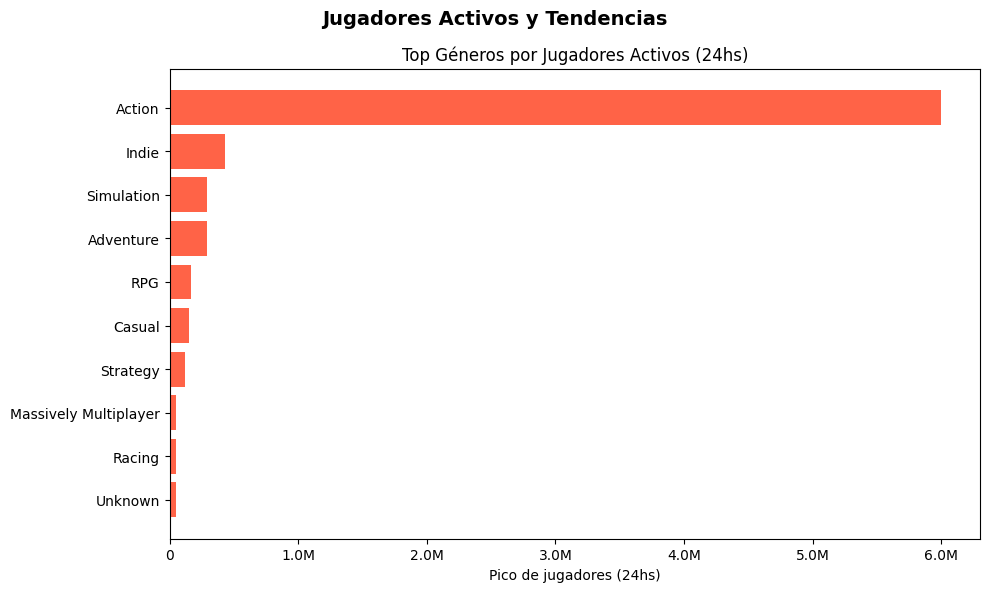

In [79]:
# ============================================================
# BLOQUE 5 — JUGADORES ACTIVOS Y TENDENCIAS
# ============================================================
# Por qué está acá: el revenue mira el pasado, los jugadores
# activos miran el presente. Este bloque identifica qué géneros
# tienen comunidades vivas hoy, lo cual es clave para una
# empresa que quiere lanzar un juego nuevo.
#
# Pregunta que responde:
#   - ¿Qué géneros tienen más jugadores activos ahora?

fig, ax = plt.subplots(figsize=(10, 6)) # Changed to single subplot and adjusted figure size
fig.suptitle('Jugadores Activos y Tendencias', fontsize=14, fontweight='bold')

# Top géneros por pico de jugadores activos
jugadores_por_genero = df.groupby('Primary_Genre')['24h_Peak_Players'].sum().sort_values(ascending=False).head(10)
ax.barh(jugadores_por_genero.index[::-1], jugadores_por_genero.values[::-1], color='tomato')
ax.set_title('Top Géneros por Jugadores Activos (24hs)')
ax.set_xlabel('Pico de jugadores (24hs)')
ax.xaxis.set_major_formatter(FuncFormatter(player_formatter))

plt.tight_layout()
plt.show()

In [80]:
# ============================================================
# BLOQUE 6 — CONCLUSIONES Y RECOMENDACIONES
# ============================================================
# Por qué está acá: este es el producto final de la consultora.
# No alcanza con mostrar datos, hay que traducirlos en decisiones
# concretas para el cliente.
#
# Preguntas que responde:
#   - ¿En qué género debería invertir una empresa nueva?
#   - ¿A qué precio debería lanzar su juego?
#   - ¿Vale la pena apuntar a Steam Deck? (Eliminado por pedido del cliente)

mejor_genero_revenue = revenue_total.index[0]
mejor_genero_jugadores = jugadores_por_genero.index[0]
precio_optimo = revenue_por_rango.idxmax()

print("=" * 55)
print("   RECOMENDACIONES — STEAM GAMES CONSULTORA")
print("=" * 55)

print(f"""
GÉNERO RECOMENDADO PARA INVERSIÓN:
  → Por revenue total:      {mejor_genero_revenue}
  → Por jugadores activos:  {mejor_genero_jugadores}

ESTRATEGIA DE PRECIO SUGERIDA:
  → El rango con mejor revenue promedio es: {precio_optimo}

CONCLUSIÓN GENERAL:
  Una empresa que quiera entrar al mercado de Steam
  debería apuntar a géneros con alta demanda activa
  y revenue sostenido, con un precio en el rango óptimo
  identificado.
""")

   RECOMENDACIONES — STEAM GAMES CONSULTORA

GÉNERO RECOMENDADO PARA INVERSIÓN:
  → Por revenue total:      Action
  → Por jugadores activos:  Action

ESTRATEGIA DE PRECIO SUGERIDA:
  → El rango con mejor revenue promedio es: $50-100

CONCLUSIÓN GENERAL:
  Una empresa que quiera entrar al mercado de Steam
  debería apuntar a géneros con alta demanda activa
  y revenue sostenido, con un precio en el rango óptimo
  identificado.

